In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from itertools import islice
import io


In [16]:
def reading(file_path, start_line, num_entries, head_names):
    #open the file to read the data from the frame
    with open(file_path, "r") as f:
        #header block of the data that needs to be iterated through
        header_block = islice(f, start_line-1, num_entries + start_line)
        #new datafram to store the read data
        new_df = pd.read_csv(io.StringIO("".join(header_block)),
                             sep='\s+',
                             header=None,
                             names=head_names)

    #returning the new dataframe    
    return new_df



In [17]:
hed_file = "c:\WINDLAB_SUMMER\ee1\ADW100o100D016a1950\ADW100o100D016a1950.hed"
start_line = 344
num_entries = 504
head_names = ['Tap_No', 'Face_No', 'X', 'Y', 'Z']
tap_df = reading(hed_file, start_line, num_entries, head_names)
print(tap_df)


     Tap_No  Face_No      X      Y      Z
0     104.0      3.0  34.36  125.0   4.00
1     105.0      3.0  34.36  125.0   9.00
2     106.0      3.0  34.36  125.0  14.00
3     107.0      3.0  34.36  125.0  16.64
4     108.0      3.0  28.71  125.0  14.00
..      ...      ...    ...    ...    ...
499  4015.0      3.0  68.21  125.0   4.00
500  4016.0      3.0  73.86  125.0   4.00
501  4101.0      3.0  79.50  125.0   3.17
502  4210.0      0.0  41.00   62.5   0.00
503  4211.0      0.0  39.00   62.5   0.00

[504 rows x 5 columns]


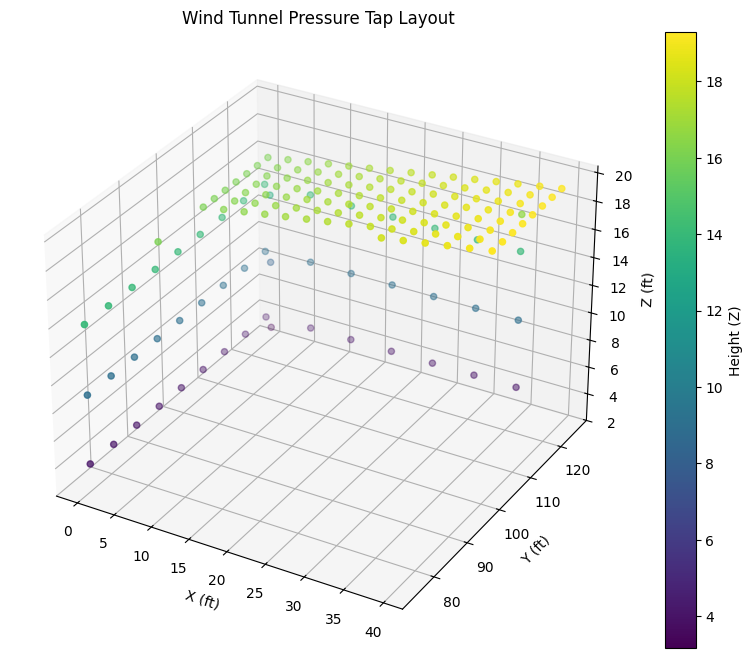

In [9]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = tap_df['X']
y = tap_df['Y']
z = tap_df['Z']
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=20)

ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
ax.set_zlabel('Z (ft)')
ax.set_title('Wind Tunnel Pressure Tap Layout')

plt.colorbar(scatter, label='Height (Z)')

plt.show()


In [ ]:
#this takes the wind speed profile table and puts it into a dataframe
start_line_speed = 217
num_entries_speed = 42
head_names_speed = ['H', 'V Ratio','Iu', 'Iv', 'Iw']


wind_speed_df = reading(hed_file, start_line_speed, num_entries_speed, head_names_speed)
print(wind_speed_df.head())

      H  V Ratio      Iu   Iv   Iw
0  1.27    0.453  24.313  0.0  0.0
1  1.27    0.451  23.589  0.0  0.0
2  3.05    0.553  20.436  0.0  0.0
3  3.66    0.557  19.256  0.0  0.0
4  4.88    0.590  18.999  0.0  0.0


In [ ]:
#building corners and frame with lines dataframe as well as python imaging
#using these 2 dfs together will help to create the final image of the building (next kernel)

#using reading function to created dataframe of corners
start_line_corners = 303
num_entires_corners = 10
head_names_corners = ['X', 'Y', 'Z']
corners_df = reading(hed_file, start_line_corners, num_entires_corners, head_names_corners)
print(corners_df)
#using reading function to create dataframe of the line to create the frame of the building
start_line_frame = 321
num_entries_frame = 15
head_names_frames = ['Start', 'End']
frames_df = reading(hed_file, start_line_frame,num_entries_frame, head_names_frames)
print(frames_df)

#here we are creating the new 0 indexed frames dataframe so that it can match the 0'd corner coordinates
frames_df['Start_0'] = frames_df['Start'] - 1
frames_df['End_0'] = frames_df['End'] - 1
print(frames_df)

frames_0_df = frames_df.drop(columns=['Start','End'])
print(frames_0_df)


      X      Y       Z
0   0.0    0.0   0.000
1   0.0  125.0   0.000
2  80.0  125.0   0.000
3  80.0    0.0   0.000
4   0.0    0.0  16.000
5   0.0  125.0  16.000
6  40.0  125.0  19.333
7  80.0  125.0  16.000
8  80.0    0.0  16.000
9  40.0    0.0  19.333
    Start  End
0       1    2
1       1    5
2       1    4
3       2    6
4       2    3
5      10    5
6      10    9
7      10    7
8       8    7
9       8    9
10      8    3
11      4    9
12      4    3
13      5    6
14      6    7
    Start  End  Start_0  End_0
0       1    2        0      1
1       1    5        0      4
2       1    4        0      3
3       2    6        1      5
4       2    3        1      2
5      10    5        9      4
6      10    9        9      8
7      10    7        9      6
8       8    7        7      6
9       8    9        7      8
10      8    3        7      2
11      4    9        3      8
12      4    3        3      2
13      5    6        4      5
14      6    7        5      6
    Start_0

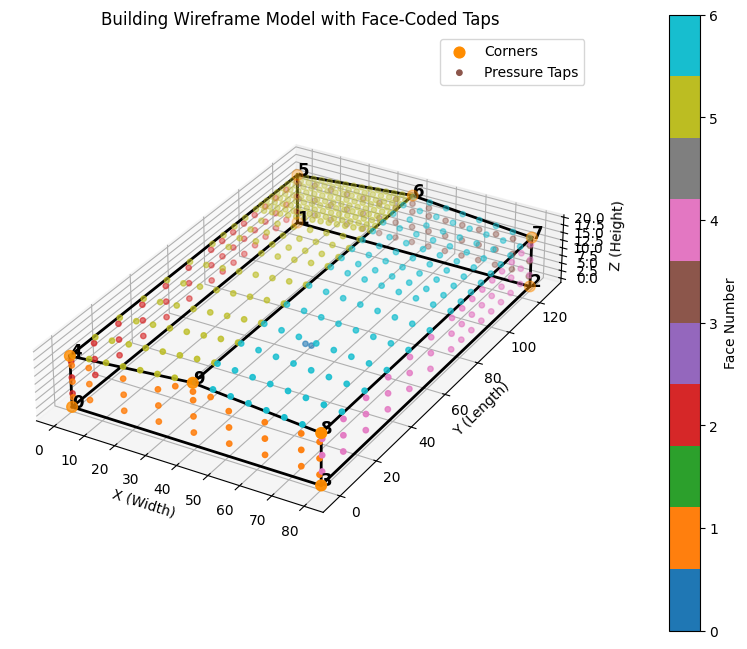

In [52]:
#this is where we will create the rendered building image using the corner and frame information given


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(corners_df['X'], corners_df['Y'], corners_df['Z'], 
           color='darkorange', s=60, label='Corners')

for _, line in frames_0_df.iterrows():
    start_id = int(line['Start_0'])
    end_id = int(line['End_0'])

    start_node = corners_df.iloc[start_id]
    end_node = corners_df.iloc[end_id]

    xs = [start_node['X'], end_node['X']]
    ys = [start_node['Y'], end_node['Y']]
    zs = [start_node['Z'], end_node['Z']]
    
    ax.plot(xs, ys, zs, color='black', linewidth=2)

for i, row in corners_df.iterrows():
    ax.text(row['X'], row['Y'], row['Z'], str(i), fontsize=12, fontweight='bold')


#now we superimpose the pressure taps on top of the building :))) 
scatter = ax.scatter(tap_df['X'], tap_df['Y'], tap_df['Z'], 
                     c=tap_df['Face_No'], 
                     cmap='tab10', 
                     s=15, 
                     label='Pressure Taps')

cbar = plt.colorbar(scatter, ax = ax, pad=0.1)
cbar.set_label('Face Number')


ax.set_xlabel('X (Width)')
ax.set_ylabel('Y (Length)')
ax.set_zlabel('Z (Height)')
ax.set_title('Building Wireframe Model with Face-Coded Taps')


ax.set_box_aspect([80, 125, 20]) 
ax.legend()
plt.show()

In [ ]:
#Now We will do the flat coordinates and see what that gives as a test :D

start_line_corners_flat = 856
num_entries_corners_flat = 28
head_names_corners_flat = ['X', 'Y']
flat_corners_df = reading(hed_file, start_line_corners_flat, num_entries_corners_flat, head_names_corners_flat)
print(flat_corners_df)

#using reading function to create dataframe of the line to create the frame of the building
start_line_frame_flat = 892
num_entries_frame_flat = 31
head_names_frames_flat = ['Start', 'End']
flat_frames_df = reading(hed_file, start_line_frame_flat,num_entries_frame_flat, head_names_frames_flat)
print(flat_frames_df)

#here we are creating the new 0 indexed frames dataframe so that it can match the 0'd corner coordinates
flat_frames_df['Start_0'] = flat_frames_df['Start'] - 1
flat_frames_df['End_0'] = flat_frames_df['End'] - 1
print(flat_frames_df)

flat_frames_0_df = flat_frames_df.drop(columns=['Start','End'])
print(flat_frames_0_df)

          X        Y
0     0.000  -27.333
1     0.000  -11.333
2    40.000   -8.000
3    80.000  -11.333
4    80.000  -27.333
5   -27.333    0.000
6   -27.333  125.000
7   -11.333  125.000
8    -8.000  125.000
9    -8.000    0.000
10  -11.333    0.000
11    0.000    0.000
12    0.000  125.000
13   40.000  125.000
14   80.000  125.000
15   80.000    0.000
16   40.000    0.000
17   88.000    0.000
18   88.000  125.000
19   91.333  125.000
20  107.333  125.000
21  107.333    0.000
22   91.333    0.000
23    0.000  136.333
24    0.000  152.333
25   80.000  152.333
26   80.000  136.333
27   40.000  133.000
    Start  End
0       1    2
1       2    3
2       3    4
3       4    5
4       5    1
5       6    7
6       7    8
7       8    9
8       9   10
9      10   11
10     11    6
11      8   11
12     12   13
13     13   14
14     14   15
15     15   16
16     16   17
17     17   12
18     14   17
19     18   19
20     19   20
21     20   21
22     21   22
23     22   23
24     23   18
2

In [ ]:
#this is where we will create the rendered building image using the corner and frame information given


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(11, projection='2d')


ValueError: Unknown projection '2d'

<Figure size 1000x800 with 0 Axes>